In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Model ve preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Modeller
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis
)
from xgboost import XGBClassifier

# Metrikler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

# SMOTE & Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


In [19]:
df = pd.read_csv("Dyt-desktop.csv", sep=";")
df.head()

,Gender,Nativelang,Otherlang,Age,Clicks1,Hits1,Misses1,Score1,Accuracy1,Missrate1,...,Score31,Accuracy31,Missrate31,Clicks32,Hits32,Misses32,Score32,Accuracy32,Missrate32,Dyslexia
0,Male,No,Yes,7,10,10,0,10,1.0,0.0,...,0,0.000000,0.00,17,2,0,2,0.117647,0.000000,No
1,Female,Yes,Yes,13,12,12,0,12,1.0,0.0,...,4,0.114286,0.00,26,2,2,2,0.076923,0.076923,Yes
2,Female,No,Yes,7,6,6,0,6,1.0,0.0,...,4,0.114286,0.00,26,1,3,1,0.038462,0.115385,No
3,Female,No,Yes,7,0,0,0,0,0.0,0.0,...,0,0.000000,0.00,1,0,0,0,0.000000,0.000000,No
4,Female,No,Yes,8,4,4,0,4,1.0,0.0,...,1,25.000000,0.05,26,2,2,2,0.076923,0.076923,No


In [20]:
categorical_cols = ["Gender", "Nativelang", "Otherlang", "Dyslexia"]

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])


In [21]:
X = df.drop("Dyslexia", axis=1)
y = df["Dyslexia"]

print("SMOTE öncesi sınıf dağılımı:")
print(y.value_counts())

SMOTE öncesi sınıf dağılımı:
Dyslexia
0    3252
1     392
Name: count, dtype: int64


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y)

In [23]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Extra Trees": ExtraTreesClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(),
    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        use_label_encoder=False
    )
}



MODEL: Logistic Regression
Accuracy : 0.8176
Precision: 0.3373
Recall   : 0.7308
F1 Score : 0.4615
ROC AUC  : 0.8386


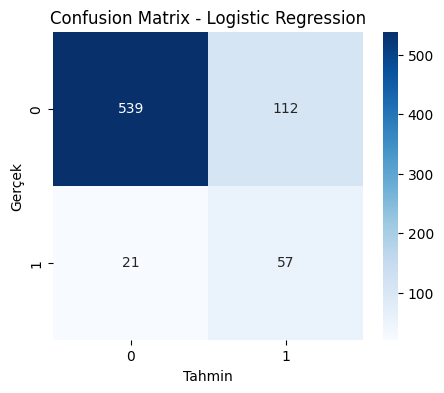


MODEL: Decision Tree
Accuracy : 0.8326
Precision: 0.2755
Recall   : 0.3462
F1 Score : 0.3068
ROC AUC  : 0.6185


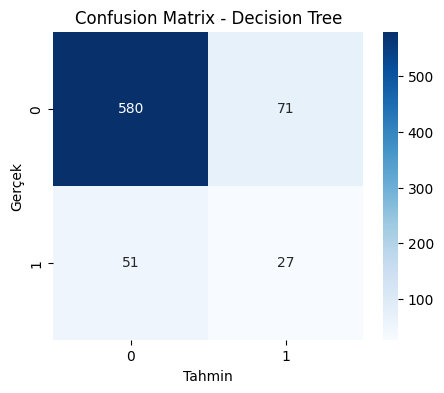


MODEL: Random Forest
Accuracy : 0.9026
Precision: 0.6400
Recall   : 0.2051
F1 Score : 0.3107
ROC AUC  : 0.8651


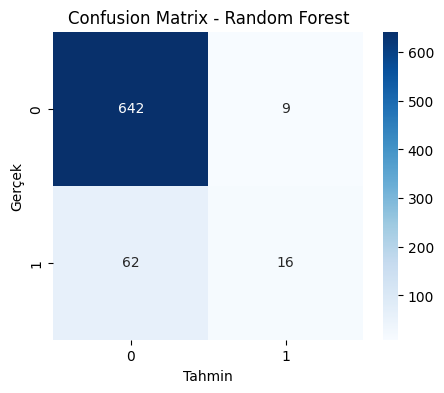


MODEL: Gradient Boosting
Accuracy : 0.8971
Precision: 0.5319
Recall   : 0.3205
F1 Score : 0.4000
ROC AUC  : 0.8711


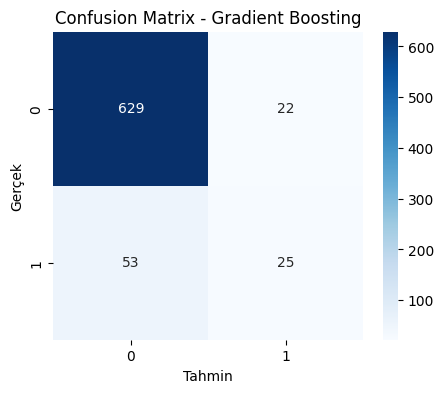


MODEL: AdaBoost
Accuracy : 0.8724
Precision: 0.4118
Recall   : 0.4487
F1 Score : 0.4294
ROC AUC  : 0.8203


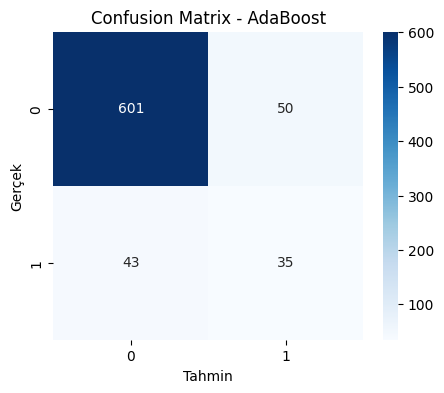


MODEL: Extra Trees
Accuracy : 0.9053
Precision: 0.6957
Recall   : 0.2051
F1 Score : 0.3168
ROC AUC  : 0.8707


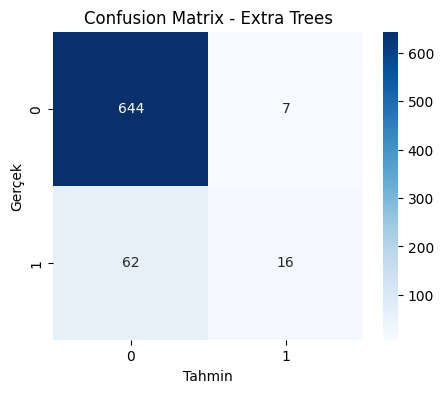


MODEL: SVM
Accuracy : 0.8957
Precision: 0.5109
Recall   : 0.6026
F1 Score : 0.5529
ROC AUC  : 0.8611


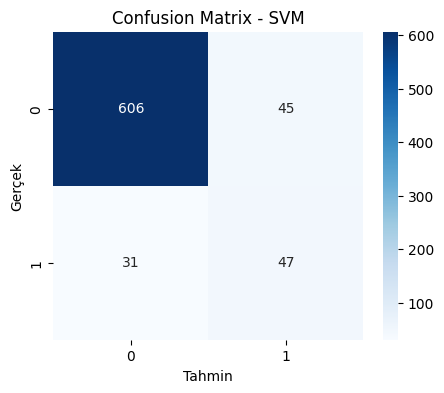


MODEL: KNN
Accuracy : 0.5816
Precision: 0.1710
Recall   : 0.7564
F1 Score : 0.2790
ROC AUC  : 0.7220


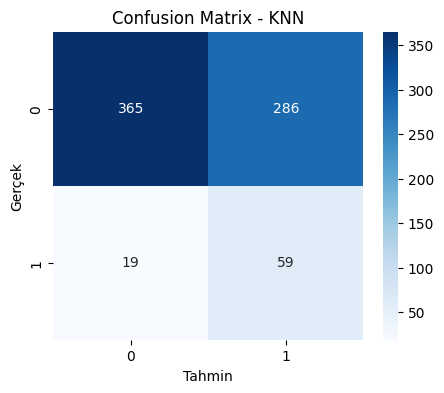


MODEL: Naive Bayes
Accuracy : 0.4362
Precision: 0.1388
Recall   : 0.8205
F1 Score : 0.2375
ROC AUC  : 0.6278


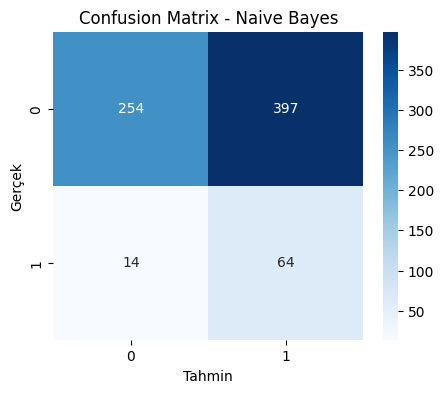


MODEL: LDA
Accuracy : 0.7888
Precision: 0.3081
Recall   : 0.7821
F1 Score : 0.4420
ROC AUC  : 0.8701


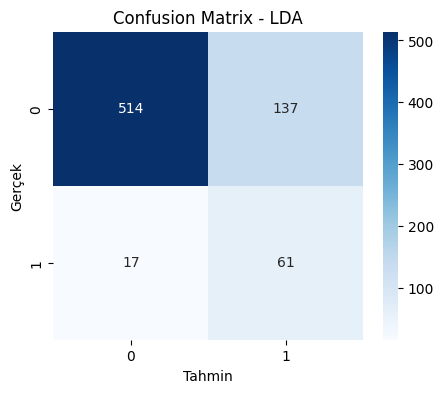


MODEL: QDA
Accuracy : 0.4829
Precision: 0.1449
Recall   : 0.7821
F1 Score : 0.2445
ROC AUC  : 0.6082


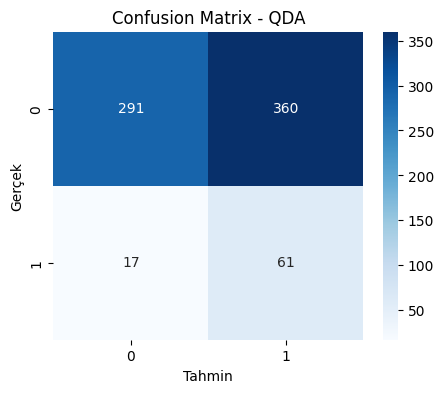


MODEL: XGBoost
Accuracy : 0.9040
Precision: 0.6111
Recall   : 0.2821
F1 Score : 0.3860
ROC AUC  : 0.8820


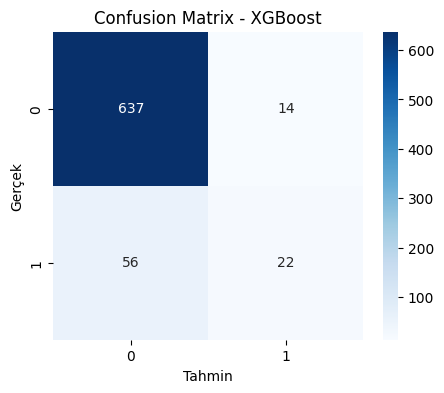

In [24]:
results = []

for name, model in models.items():
    print(f"\nMODEL: {name}")
    print("="*35)

    pipe = ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    # Olasılık (ROC için)
    y_proba = (
        pipe.predict_proba(X_test)[:, 1]
        if hasattr(pipe["model"], "predict_proba")
        else None
    )

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    if roc_auc:
        print(f"ROC AUC  : {roc_auc:.4f}")

    results.append([name, acc, prec, rec, f1, roc_auc])

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Tahmin")
    plt.ylabel("Gerçek")
    plt.show()


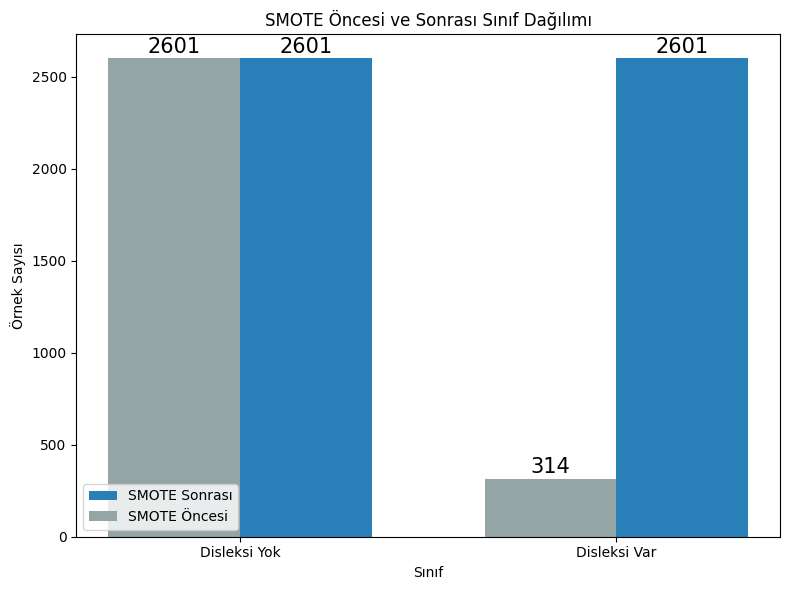

In [36]:
before_counts = y_train.value_counts().sort_index()

smote_vis = SMOTE(random_state=42)
X_train_smote_vis, y_train_smote_vis = smote_vis.fit_resample(X_train, y_train)

after_counts = y_train_smote_vis.value_counts().sort_index()
labels = ["Disleksi Yok", "Disleksi Var"]
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 6))

# SMOTE Sonrası
plt.bar(
    x + width/2,
    after_counts.values,
    width,
    label="SMOTE Sonrası",
    color="#2980b9"
)

# SMOTE Öncesi
plt.bar(
    x - width/2,
    before_counts.values,
    width,
    label="SMOTE Öncesi",
    color="#95a5a6"
)

plt.xticks(x, labels)
plt.xlabel("Sınıf")
plt.ylabel("Örnek Sayısı")
plt.title("SMOTE Öncesi ve Sonrası Sınıf Dağılımı")
plt.legend()

# Bar üstüne değer yazma
for i in range(len(labels)):
    plt.text(
        x[i] - width/2,
        before_counts.values[i] + 30,
        before_counts.values[i],
        ha="center",
        fontsize=15)
    plt.text(
        x[i] + width/2,
        after_counts.values[i] + 30,
        after_counts.values[i],
        ha="center",
        fontsize=15
    )

plt.tight_layout()
plt.show()


In [26]:
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1", "ROC AUC"]
)

print("\n--- TÜM MODEL SONUÇLARI ---")
print(results_df)



--- TÜM MODEL SONUÇLARI ---
                  Model  Accuracy  Precision    Recall        F1   ROC AUC
0   Logistic Regression  0.817558   0.337278  0.730769  0.461538  0.838592
1         Decision Tree  0.832647   0.275510  0.346154  0.306818  0.618545
2         Random Forest  0.902606   0.640000  0.205128  0.310680  0.865070
3     Gradient Boosting  0.897119   0.531915  0.320513  0.400000  0.871086
4              AdaBoost  0.872428   0.411765  0.448718  0.429448  0.820296
5           Extra Trees  0.905350   0.695652  0.205128  0.316832  0.870672
6                   SVM  0.895748   0.510870  0.602564  0.552941  0.861101
7                   KNN  0.581619   0.171014  0.756410  0.278960  0.721986
8           Naive Bayes  0.436214   0.138829  0.820513  0.237477  0.627792
9                   LDA  0.788752   0.308081  0.782051  0.442029  0.870121
10                  QDA  0.482853   0.144893  0.782051  0.244489  0.608196
11              XGBoost  0.903978   0.611111  0.282051  0.385965  0.881

In [27]:
results_df_sorted = results_df.sort_values(by="Recall", ascending=False)
print("\n--- RECALL'A GÖRE SIRALAMA ---")
print(results_df_sorted)



--- RECALL'A GÖRE SIRALAMA ---
                  Model  Accuracy  Precision    Recall        F1   ROC AUC
8           Naive Bayes  0.436214   0.138829  0.820513  0.237477  0.627792
9                   LDA  0.788752   0.308081  0.782051  0.442029  0.870121
10                  QDA  0.482853   0.144893  0.782051  0.244489  0.608196
7                   KNN  0.581619   0.171014  0.756410  0.278960  0.721986
0   Logistic Regression  0.817558   0.337278  0.730769  0.461538  0.838592
6                   SVM  0.895748   0.510870  0.602564  0.552941  0.861101
4              AdaBoost  0.872428   0.411765  0.448718  0.429448  0.820296
1         Decision Tree  0.832647   0.275510  0.346154  0.306818  0.618545
3     Gradient Boosting  0.897119   0.531915  0.320513  0.400000  0.871086
11              XGBoost  0.903978   0.611111  0.282051  0.385965  0.881996
2         Random Forest  0.902606   0.640000  0.205128  0.310680  0.865070
5           Extra Trees  0.905350   0.695652  0.205128  0.316832  0.

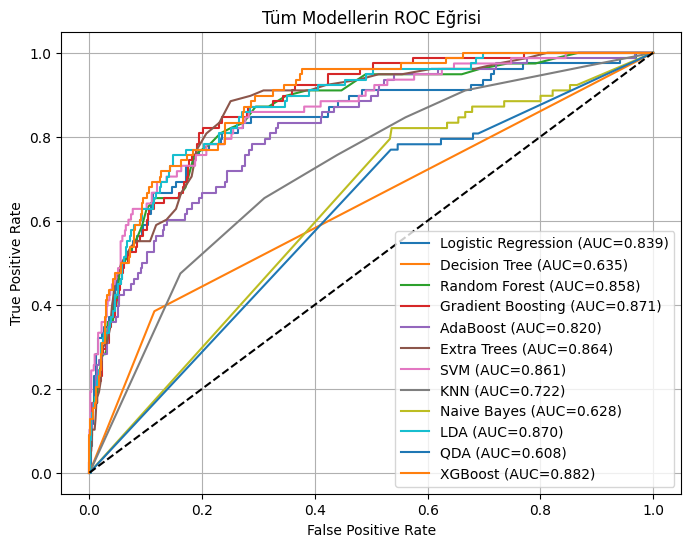

In [28]:
plt.figure(figsize=(8,6))

for name, model in models.items():
    pipe = ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    if hasattr(pipe["model"], "predict_proba"):
        y_proba = pipe.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc_score = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.3f})")

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Tüm Modellerin ROC Eğrisi")
plt.legend()
plt.grid()
plt.show()


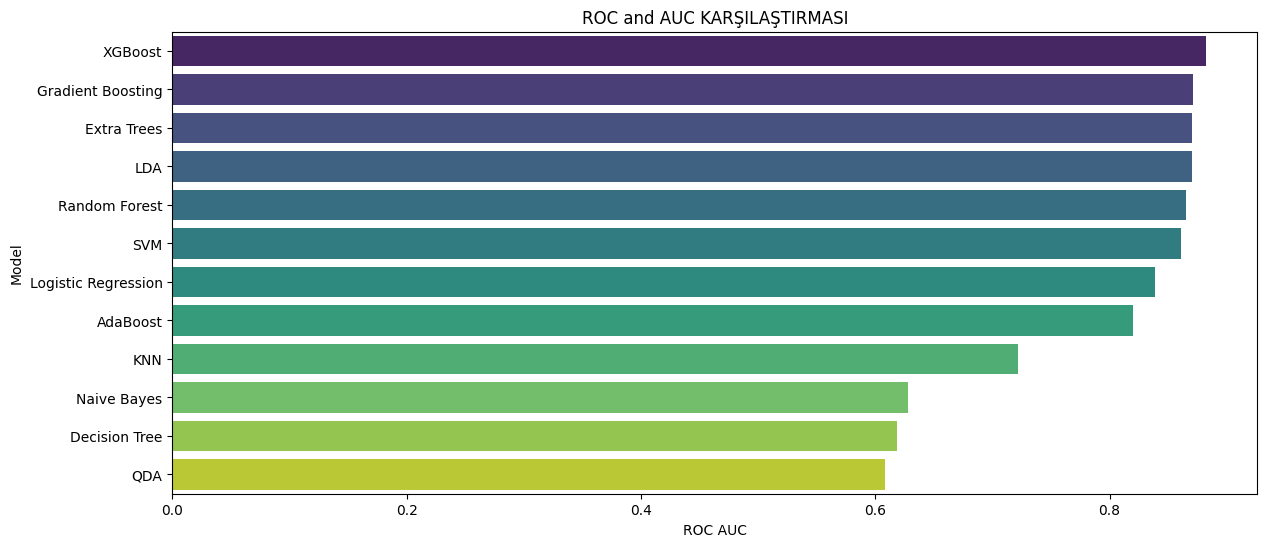

In [29]:
plt.figure(figsize=(14,6))
sns.barplot(data=results_df.sort_values('ROC AUC' , ascending=False),
            x='ROC AUC' , y='Model' , palette='viridis')

plt.title('ROC and AUC KARŞILAŞTIRMASI')
plt.show()

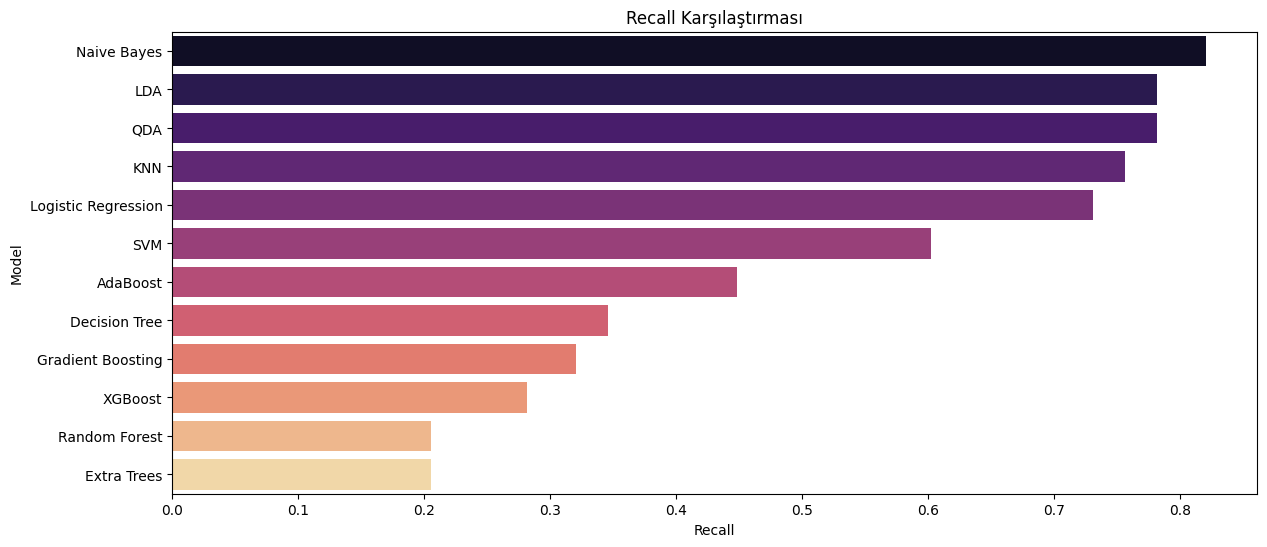

In [30]:
plt.figure(figsize=(14,6))
sns.barplot(data=results_df.sort_values('Recall' , ascending=False),
            x='Recall' , y='Model' , palette='magma')
plt.title('Recall Karşılaştırması')
plt.show()